<a href="https://colab.research.google.com/github/Navya28-khanna/ML_LAB/blob/main/Test_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score


In [15]:
#load dataset
df = pd.read_csv("spam_ham_dataset.csv")

print(df.head())
print("Columns:", df.columns)
print("Unique labels BEFORE:", df['label'].unique())

   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
Columns: Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')
Unique labels BEFORE: ['ham' 'spam']


In [6]:
# Define X and y

X = df['text']
y = df['label']

In [16]:
#data preprocessing

df = df.dropna()

if df['label'].dtype == 'object':
    df['label'] = df['label'].astype(str).str.strip().str.lower()

    if set(df['label'].unique()) == {'spam', 'ham'}:
        df['label'] = df['label'].map({'spam': 1, 'ham': 0})
    else:
        print("⚠️ Labels are not 'spam/ham', keeping original values")

print("Dataset size:", df.shape)




Dataset size: (5171, 4)


In [18]:
# 4. Features

X = df['text'].apply(len).values.reshape(-1, 1)
y = df['label']

print("X shape:", X.shape)
# 5. Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



X shape: (5171, 1)


In [19]:
# 6. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# 7. Train Model

model = GaussianNB()
model.fit(X_train, y_train)
print("Testing size:", X_test.shape)

Testing size: (1035, 1)


In [20]:

# 8. Predictions

y_pred = model.predict(X_test)


# 9. Evaluation

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[721  21]
 [276  17]]
Accuracy: 0.7130434782608696


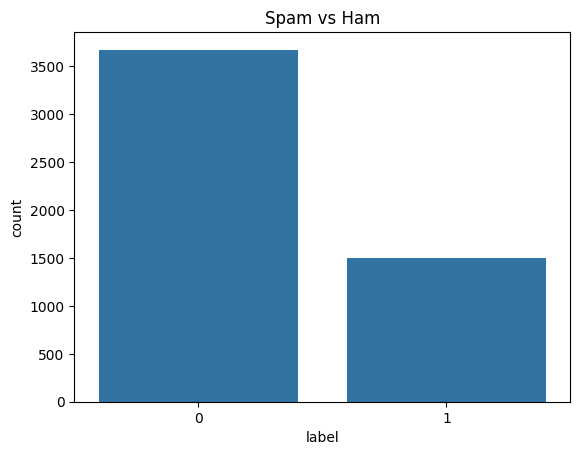

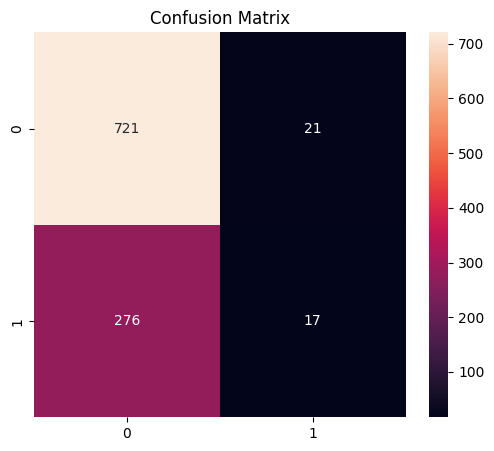

In [21]:
# 10. Visualization

sns.countplot(x=y)
plt.title("Spam vs Ham")
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()